In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import matplotlib.ticker as mtick
import statsmodels.api as sm
from scipy import stats
import pandas_datareader as pdr
import io, zipfile, requests

### **Setting Parameters** [IMPORTANT] ###

I think for now let's just assume monthly = true

In [128]:
monthly = False # set "monthly = false" if we're using daily returns.
# This will change the ENTIRE output of the program so use carefully.

start_date = ""  #Date format: yyyy-mm-dd
end_date = ""  #leave these blank ("") if no specific start / end date

ticker = "URTH" #Benchmark Ticker (Yahoo Finance). Not used in Fama-French Cahart regression

fund_data_path = "M:/_Intern Folder/Matthew/Fundsmith_Daily_Returns.xlsx" # Must be in .xlsx format
# Must have only 2 columns called Date and Return (in decimals)

### Data Pulling & Cleaning ###

In [129]:
#Get fund returns data (depends on fund)
fund_data_path
fund_data = pd.read_excel(fund_data_path)  
fund_data = fund_data[['Date', 'Return']].dropna() 

# Prepare fund returns
fund_data['Date'] = pd.to_datetime(fund_data['Date'])
fund_data = fund_data.set_index('Date').sort_index()
# Returns must be in decimals (no percentages)

fund_data

,Return
Date,
2013-03-15,0.008090
2013-03-18,-0.004156
2013-03-19,-0.000956
2013-03-20,0.001745
2013-03-21,0.003235
...,...
2026-02-26,0.005509
2026-02-27,0.001643
2026-03-02,-0.011529


In [130]:
def fetch_ff_csv(name, monthly=True, start="2000-01-01"):
    """Download a Fama-French CSV dataset and return monthly or daily table as a DataFrame."""
    url = f"https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/{name}_CSV.zip"
    resp = requests.get(url)
    resp.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        csv_name = [n for n in zf.namelist() if n.lower().endswith(".csv")][0]
        raw = zf.read(csv_name).decode("utf-8")

    # Monthly rows use YYYYMM, daily rows use YYYYMMDD
    expected_len = 6 if monthly else 8

    lines = raw.strip().splitlines()
    header, data = None, []
    for i, line in enumerate(lines):
        token = line.strip().split(",")[0].strip()
        if token.isdigit() and len(token) == expected_len:
            if header is None:
                header = lines[i - 1]
            data.append(line)
        elif data:
            break  # stop at end of first numeric block

    df = pd.read_csv(io.StringIO(header + "\n" + "\n".join(data)))
    df.columns = df.columns.str.strip()
    df = df.rename(columns={df.columns[0]: "Date"})

    fmt = "%Y%m" if monthly else "%Y%m%d"
    df["Date"] = pd.to_datetime(df["Date"].astype(str), format=fmt, errors="coerce")
    df = df.dropna(subset=["Date"]).set_index("Date").sort_index()

    if monthly == True:
        df.index = df.index.to_period("M").to_timestamp("M")

    # Fama-French values are in percent, convert to decimals
    return df[df.index >= pd.Timestamp(start)] / 100


ff3_name = "F-F_Research_Data_Factors" if monthly else "F-F_Research_Data_Factors_daily"
mom_name = "F-F_Momentum_Factor" if monthly else "F-F_Momentum_Factor_daily"

ff3 = fetch_ff_csv(ff3_name, monthly=monthly)
mom = fetch_ff_csv(mom_name, monthly=monthly)
mom.columns = ["MOM"]

ff4 = ff3.join(mom, how="inner")
print(f"Carhart 4-Factor: {ff4.shape[0]} rows x {ff4.shape[1]} cols")
ff4

Carhart 4-Factor: 6559 rows x 5 cols


,Mkt-RF,SMB,HML,RF,MOM
Date,,,,,
2000-01-03,-0.0071,0.0055,-0.0131,0.0002,-0.0006
2000-01-04,-0.0406,-0.0002,0.0207,0.0002,-0.0191
2000-01-05,-0.0009,0.0031,-0.0005,0.0002,-0.0049
2000-01-06,-0.0074,-0.0043,0.0124,0.0002,-0.0149
2000-01-07,0.0321,-0.0040,-0.0157,0.0002,0.0059
...,...,...,...,...,...
2026-01-26,0.0040,-0.0074,-0.0023,0.0002,0.0045
2026-01-27,0.0034,-0.0004,0.0022,0.0002,0.0259
2026-01-28,-0.0010,-0.0105,0.0039,0.0002,0.0045


In [131]:
#get fund returns
fund_rets = fund_data['Return']

#SANITY CHECKS


# Align series on common dates
df = pd.concat([fund_rets, ff4], axis=1, join='inner')

# Check if start / end date is specified
if start_date != "" and end_date != "":
    df = df.loc[start_date:end_date]
elif start_date != "" and end_date == "":
    df = df.loc[start_date:]
elif start_date == "" and end_date != "":
    df = df.loc[:end_date]

fund_data_concatenated = df.copy()

df['Return-RF'] = df['Return'] - df['RF']
df

,Return,Mkt-RF,SMB,HML,RF,MOM,Return-RF
Date,,,,,,,
2013-03-15,0.008090,-0.0019,0.0002,0.0040,0.0000,-0.0059,0.008090
2013-03-18,-0.004156,-0.0050,0.0015,-0.0029,0.0000,0.0000,-0.004156
2013-03-19,-0.000956,-0.0023,-0.0001,0.0001,0.0000,0.0028,-0.000956
2013-03-20,0.001745,0.0076,0.0025,-0.0001,0.0000,0.0042,0.001745
2013-03-21,0.003235,-0.0085,0.0018,-0.0027,0.0000,0.0008,0.003235
...,...,...,...,...,...,...,...
2026-01-26,0.000488,0.0040,-0.0074,-0.0023,0.0002,0.0045,0.000288
2026-01-27,0.007043,0.0034,-0.0004,0.0022,0.0002,0.0259,0.006843
2026-01-28,-0.005786,-0.0010,-0.0105,0.0039,0.0002,0.0045,-0.005986


In [132]:
#check if any data is lost
fund_data_concatenated = df.copy()

removed = (
    fund_data.reset_index()
    .merge(
        fund_data_concatenated.reset_index(),
        on='Date',
        how='left',
        indicator=True
    )
    .query('_merge == "left_only"')
    .set_index('Date')
)

removed

,Return_x,Return_y,Mkt-RF,SMB,HML,RF,MOM,Return-RF,_merge
Date,,,,,,,,,
2013-07-04,0.003997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2013-09-02,0.002635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2013-11-28,0.000520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2014-01-20,-0.002763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2014-02-17,0.006796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...
2026-02-26,0.005509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2026-02-27,0.001643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2026-03-02,-0.011529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


### Finding Beta & Alpha + Testing statistical significance of Alpha ###

In [133]:
alpha_color = "#f90e0eff"
beta_color = '#009efb'

y = df['Return-RF']

x = sm.add_constant(df[['Mkt-RF', 'SMB', 'HML', 'MOM']])

results = sm.OLS(y, x).fit()
alpha = results.params['const']
beta = results.params['Mkt-RF']
smb = results.params['SMB']
hml = results.params['HML']
mom = results.params['MOM']

In [134]:
# Build summary table from regression results
factors = ['const', 'Mkt-RF', 'SMB', 'HML', 'MOM']
labels = ['Alpha', 'Beta (Mkt-RF)', 'SMB', 'HML', 'MOM']

rows = []
for factor, label in zip(factors, labels):
    coef = results.params[factor]
    t_stat = results.tvalues[factor]
    p_two = results.pvalues[factor]
    p_one = p_two / 2
    sig = "Yes" if p_one < 0.05 else "No"
    stars = "***" if p_one < 0.01 else "**" if p_one < 0.05 else "*" if p_one < 0.10 else ""
    rows.append([label, f"{coef:.6f}", f"{t_stat:.4f}", f"{p_two:.5f}", f"{p_one:.5f}", sig, stars])

header = f"{'Factor':<18} {'Coefficient':>14} {'t-Statistic':>14} {'P (2-tail)':>14} {'P (1-tail)':>14} {'Sig (5%)':>10} {'':>4}"
print("=" * 95)
print(f"{'Fama-French 4-Factor Regression Results':^95}")
print("=" * 95)
print(header)
print("-" * 95)
for row in rows:
    print(f"{row[0]:<18} {row[1]:>14} {row[2]:>14} {row[3]:>14} {row[4]:>14} {row[5]:>10} {row[6]:>4}")
print("=" * 95)
print("Significance: *** p<0.01  ** p<0.05  * p<0.10  (one-tailed)")
print(f"R-squared: {results.rsquared:.4f}    Adj. R-squared: {results.rsquared_adj:.4f}    Obs: {int(results.nobs)}")
print("=" * 95)


                            Fama-French 4-Factor Regression Results                            
Factor                Coefficient    t-Statistic     P (2-tail)     P (1-tail)   Sig (5%)     
-----------------------------------------------------------------------------------------------
Alpha                    0.000352         2.1857        0.02891        0.01446        Yes   **
Beta (Mkt-RF)            0.104820         6.9691        0.00000        0.00000        Yes  ***
SMB                     -0.067893        -2.5754        0.01006        0.00503        Yes  ***
HML                      0.034169         1.6649        0.09603        0.04801        Yes   **
MOM                     -0.021632        -1.2798        0.20070        0.10035         No     
Significance: *** p<0.01  ** p<0.05  * p<0.10  (one-tailed)
R-squared: 0.0175    Adj. R-squared: 0.0163    Obs: 3123


### Investigating Alpha Decay using Time-Series analysis: -- Exponential Regression ###

Paper: https://ink.library.smu.edu.sg/cgi/viewcontent.cgi?article=5734&context=lkcsb_research

"Have Capital Market Anomalies Attenuated in the Recent Era of High Liquidity and Trading Activity?" -- Section 4.3

Goal: Regress alpha data onto this curve: 

$$Y_t = a \cdot e^{bt + u_t}$$

Taking logs linearizes it: 

$$\ln(Y_t) = \ln(a) + b \cdot t + u $$

where $$Y_t = 1 + alpha_t$$

Null hypothesis: Anomalous profits (alpha) decrease exponentially over time.

Alternative hypothesis: Anomalous profits (alpha) don't decrease exponentially over time.

**Interpretation**: 

- If b < 0 and one-tailed p-value < 0.10, the strategy is experiencing statistically significant exponential decay in alpha.

- If b > 0 and one-tailed p-value < 0.10, the strategy is experiencing statistically significant exponential growth in alpha.

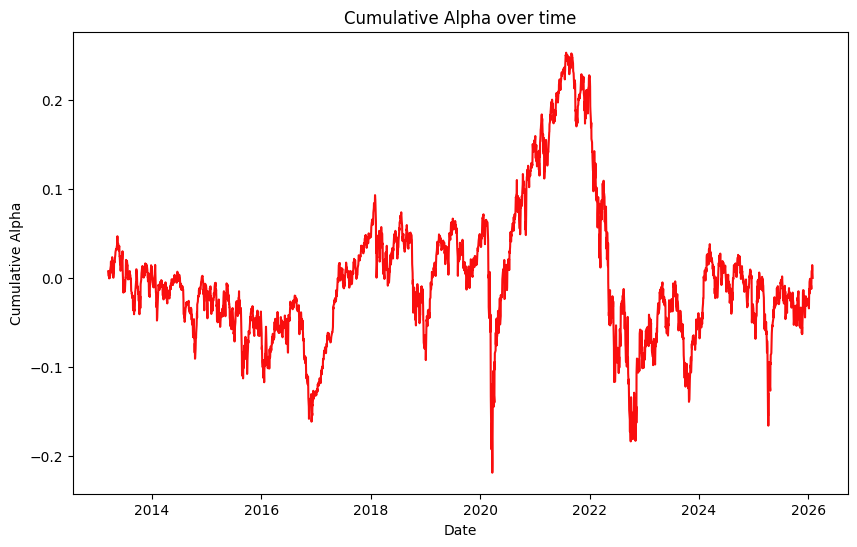

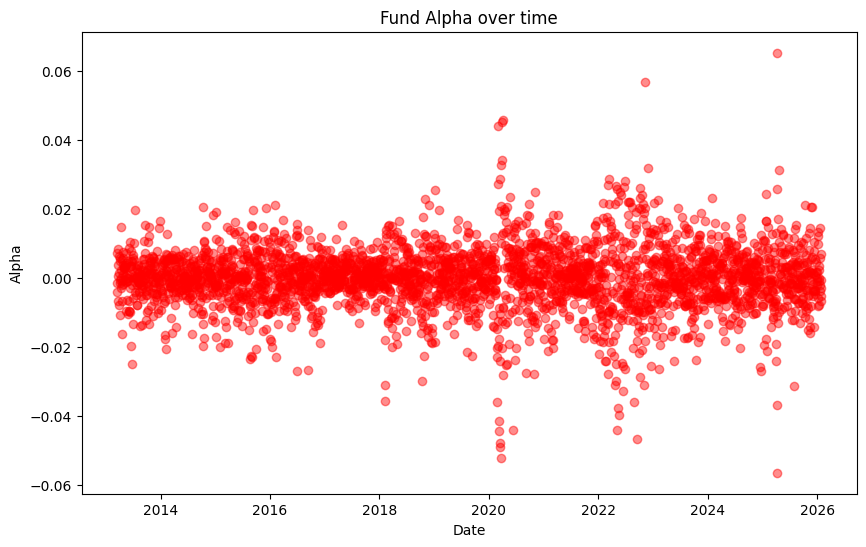

In [ ]:
df['Alpha'] = df['Return-RF'] - (df['Mkt-RF'] * beta + df['SMB'] * smb + df['HML'] * hml + df['MOM'] * mom)
df['Cumulative Alpha'] = df['Alpha'].cumsum()

fig, ax = plt.subplots(figsize=(10,6))
plt.title("Cumulative Alpha over time")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Alpha")
ax.plot(df.index, df['Cumulative Alpha'], color="#f90e0eff")

fig, ax = plt.subplots(figsize=(10,6))
plt.title("Fund Alpha over time")
ax.set_xlabel("Date")
ax.set_ylabel("Alpha")
plt.scatter(df.index, df['Alpha'], alpha=0.45, color="#ff0000ff")
df

df.to_csv("alpha_output.csv")

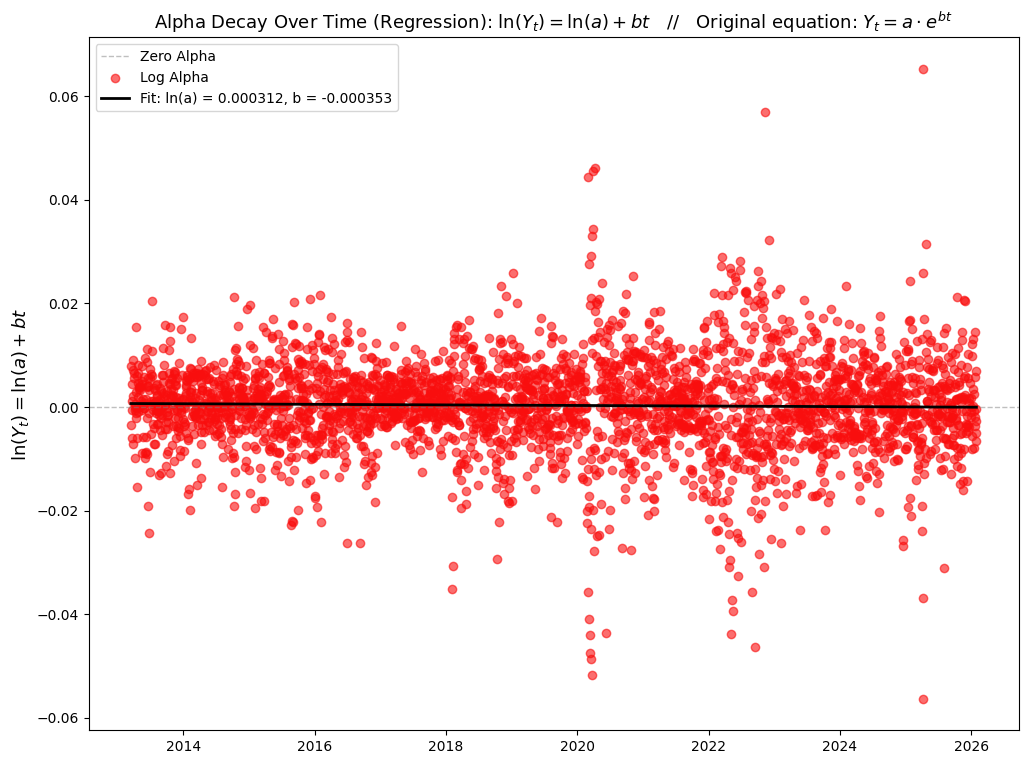

Note: This assumes that there exists a statistically significant alpha. If there is none, this decay result is pointless.
Condition: If p-value (one-tailed) < 0.10 and b < 0 (is negative), alpha decay is present at the 10% SL.
--------------------------------------------------
The p-value of the regression coefficient b (0.10273) is statistically insignificant.
There is insufficient evidence to suggest alpha decay.


In [136]:
df_alpha = df[['Alpha', 'Cumulative Alpha']].copy()
df_alpha['Log Alpha'] = np.log(1 + df_alpha['Alpha'])
df_alpha

array = np.linspace(-1, 1, len(df_alpha))
array = sm.add_constant(array)
model = sm.OLS(df_alpha['Log Alpha'], array)
results = model.fit()
# print(results.summary())

# ln_Yt = results.params['const'] + np.linspace(-1, 1, len(df_alpha)) * results.params['x1']
ln_Yt = results.fittedvalues
Y_t = np.exp(ln_Yt)

ln_a = results.params['const']
a = np.exp(ln_a)
b = results.params['x1']
p_decay_onetailed = results.pvalues['x1'] / 2

fig, ax = plt.subplots(figsize=(12,9))
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label="Zero Alpha")
plt.scatter(df_alpha.index, df_alpha['Log Alpha'], alpha=0.6, color="#f90e0eff", label="Log Alpha")
plt.title("Alpha Decay Over Time (Regression): $\ln(Y_t) = \ln(a) + bt$   //   Original equation: $Y_t = a \cdot e^{bt}$", fontsize=13)
plt.plot(
    df_alpha.index, 
    ln_Yt,
    color="#000000",
    linewidth=2,
    label=f"Fit: ln(a) = {ln_a:.6f}, b = {b:.6f}"
)
ax.set_ylabel("$\ln(Y_t) = \ln(a) + bt$", fontsize=13)
plt.legend()
plt.show()

print("Note: This assumes that there exists a statistically significant alpha. If there is none, this decay result is pointless.")
print("Condition: If p-value (one-tailed) < 0.10 and b < 0 (is negative), alpha decay is present at the 10% SL.")
print("-" * 50)

if p_decay_onetailed < 0.1 and b < 0: 
    print(f"The p-value of the regression coefficient b ({p_decay_onetailed:.5f}) is statistically significant.")
    print("There is sufficient evidence to suggest alpha decay.")
elif p_decay_onetailed > 0.1 and b < 0: 
    print(f"The p-value of the regression coefficient b ({p_decay_onetailed:.5f}) is statistically insignificant.")
    print("There is insufficient evidence to suggest alpha decay.")
elif b > 0 and p_decay_onetailed < 0.1: 
    print(f"The p-value of the regression coefficient coefficient b ({p_decay_onetailed:.5f}) is statistically significant.")
    print(f"Rare case: The fund's alpha actually increases over time and is significant enough.")
elif b > 0 and p_decay_onetailed > 0.1:
    print(f"b is positive but insignificant (p = {p_decay_onetailed:.5f}).")
    print("There is insufficient evidence of either decay or growth in alpha.")

### Plotting cumulative returns, Sharpe, and rolling market volatility ###

In [137]:
# Pull benchmark data from Yahoo Finance
market_data = yf.download(ticker, period="max", interval="1mo" if monthly else "1d", multi_level_index=False)
market_data['market_rets'] = market_data['Close'].pct_change()
market_data = market_data.dropna()
market_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume,market_rets
Date,,,,,,
2012-01-13,38.475288,38.475288,38.475288,38.475288,0,0.000000
2012-01-17,38.475288,38.475288,38.475288,38.475288,0,0.000000
2012-01-18,38.475288,38.475288,38.475288,38.475288,0,0.000000
2012-01-19,39.607353,39.607353,39.607353,39.607353,300,0.029423
2012-01-20,39.607353,39.607353,39.607353,39.607353,0,0.000000
...,...,...,...,...,...,...
2026-03-11,186.020004,186.800003,185.149994,186.059998,320500,-0.001824
2026-03-12,183.149994,184.630005,183.130005,184.429993,484400,-0.015429
2026-03-13,181.750000,184.699997,181.470001,183.779999,299700,-0.007644


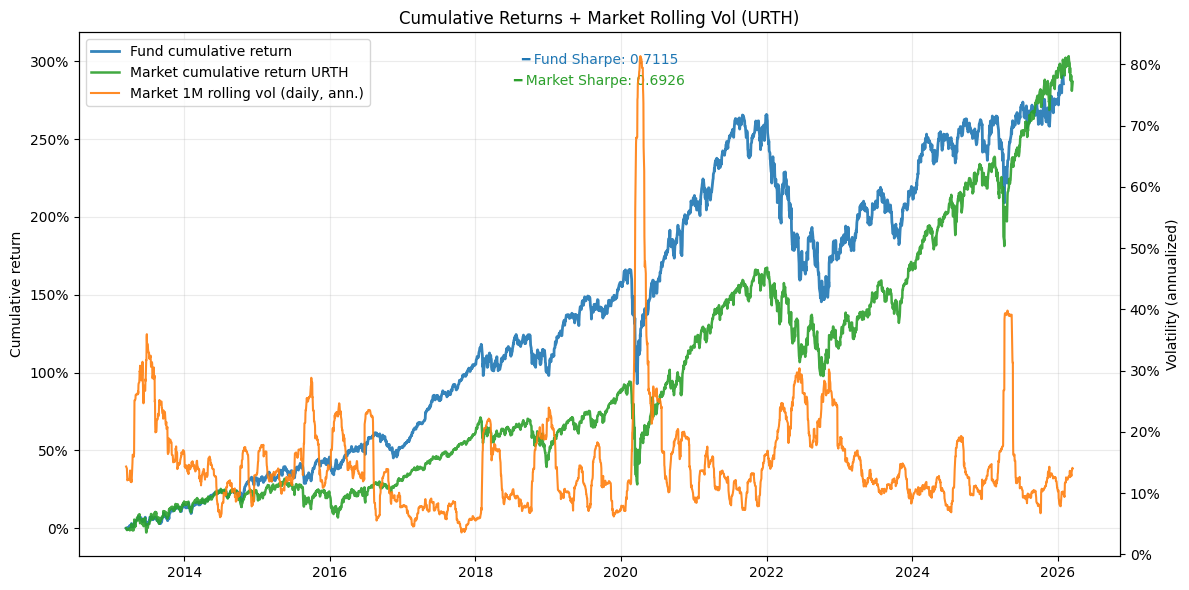

In [138]:
if monthly:
    # Sharpe and volatility -- monthly
    fund_excess_vol = df["Return-RF"].std()
    fund_excess_vol_annualized = fund_excess_vol * np.sqrt(12)
    fund_sharpe_annualized = (df["Return-RF"].mean() / fund_excess_vol) * np.sqrt(12)

    mkt_excess_vol = df["Mkt-RF"].std()
    mkt_excess_vol_annualized = mkt_excess_vol * np.sqrt(12)
    mkt_sharpe_annualized = (df["Mkt-RF"].mean() / mkt_excess_vol) * np.sqrt(12)

    # Monthly market return series
    mkt_d = market_data["market_rets"].astype(float).dropna().sort_index()
    if mkt_d.index.inferred_freq is None or "M" not in str(mkt_d.index.inferred_freq):
        mkt_d = mkt_d.resample("M").apply(lambda x: (1 + x).prod() - 1)
    mkt_d.index = mkt_d.index.to_period("M").to_timestamp("M")

    # Monthly rolling vol: 6 months annualized
    mkt_vol1m_d = mkt_d.rolling(window=6).std() * np.sqrt(12)

else:
    # Sharpe and volatility -- daily
    fund_excess_vol = df["Return-RF"].std()
    fund_excess_vol_annualized = fund_excess_vol * np.sqrt(252)
    fund_sharpe_annualized = (df["Return-RF"].mean() / fund_excess_vol) * np.sqrt(252)

    mkt_excess_vol = df["Mkt-RF"].std()
    mkt_excess_vol_annualized = mkt_excess_vol * np.sqrt(252)
    mkt_sharpe_annualized = (df["Mkt-RF"].mean() / mkt_excess_vol) * np.sqrt(252)

    # Daily market return series
    mkt_d = market_data["market_rets"].astype(float).dropna().sort_index()

    # Daily rolling vol: 30 trading days annualized
    mkt_vol1m_d = mkt_d.rolling(window=30).std() * np.sqrt(252)

# Use df Return for consistency with regression sample frequency
fund_gross = (1 + df["Return"].astype(float)).cumprod()

# choose plot start where vol exists and fund exists
start = max(df.index.min(), mkt_vol1m_d.dropna().index.min())

# rebased fund cumulative return (starts at 0 at start)
fund_plot_gross = fund_gross.loc[fund_gross.index >= start]
fund_plot_cum = fund_plot_gross / fund_plot_gross.iloc[0] - 1

# rebased market cumulative return (starts at 0 at start)
mkt_cum_gross = (1 + mkt_d).cumprod()
base = mkt_cum_gross.loc[:start].iloc[-1]
mkt_cum_plot = mkt_cum_gross.loc[mkt_cum_gross.index >= start] / base - 1

mkt_vol_plot = mkt_vol1m_d.loc[mkt_vol1m_d.index >= start]

#Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

l1, = ax1.plot(
    fund_plot_cum.index, fund_plot_cum,
    color="tab:blue", lw=2, alpha=0.9,
    label="Fund cumulative return"
)
l2, = ax1.plot(
    mkt_cum_plot.index, mkt_cum_plot,
    color="tab:green", lw=1.8, alpha=0.9,
    label=f"Market cumulative return {ticker}"
)

ax1.set_ylabel("Cumulative return")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
vol_label = "Market 6M rolling vol (monthly, ann.)" if monthly else "Market 1M rolling vol (daily, ann.)"
l3, = ax2.plot(
    mkt_vol_plot.index, mkt_vol_plot,
    color="tab:orange", lw=1.5, alpha=0.9,
    label=vol_label
)
ax2.set_ylabel("Volatility (annualized)")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax1.set_title(f"Cumulative Returns + Market Rolling Vol ({ticker})")
ax1.legend(handles=[l1, l2, l3], loc="upper left")

ax1.text(
    0.5, 0.96,
    f"━ Fund Sharpe: {fund_sharpe_annualized:.4f}",
    transform=ax1.transAxes, ha="center", va="top", color=l1.get_color()
)
ax1.text(
    0.5, 0.92,
    f"━ Market Sharpe: {mkt_sharpe_annualized:.4f}",
    transform=ax1.transAxes, ha="center", va="top", color=l2.get_color()
)

plt.tight_layout()
plt.show()

### Analysing Kurtosis & Skewness ###

In [139]:
# plt.figure(figsize=(6, 5))
# stats.probplot(df['Return'], dist="norm", plot=plt)
# plt.title("QQ Plot of Fund Raw Returns")
# plt.ylabel("Fund Returns")
# plt.xlabel("Theoretical Normal Quantiles")
# plt.show()

# plt.figure(figsize=(6, 5))
# stats.probplot(df['Market Return'], dist="norm", plot=plt)
# plt.title("QQ Plot of Market Returns")
# plt.ylabel("Market Returns")
# plt.xlabel("Theoretical Normal Quantiles")
# plt.show()

# mkt_kurtosis = df["Market Return"].kurtosis()
# mkt_skew = df["Market Return"].skew()

# fund_kurtosis = df['Return'].kurtosis()
# fund_skew = df['Return'].skew()

# print(f"Kurtosis (Fund): {fund_kurtosis:.4f}")
# print(f"Skewness (Fund):  {fund_skew:.4f}")
# print("")
# print(f"Kurtosis (Market): {mkt_kurtosis:.4f}")
# print(f"Skewness (Market):  {mkt_skew:.4f}")

# def hist_with_stats(ax, s, title, xlabel):
#     x = s.astype(float).replace([np.inf, -np.inf], np.nan).dropna()
#     mu, sigma = x.mean(), x.std(ddof=1)

#     grid = np.linspace(x.min(), x.max(), 400)
#     ax.hist(x, bins=50, density=True, alpha=0.7, edgecolor="white")
#     ax.plot(grid, stats.norm.pdf(grid, mu, sigma), "k", linewidth=2)

#     ax.set_title(title)
#     ax.set_xlabel(xlabel)
#     ax.set_ylabel("Density")
#     ax.text(
#         0.02, 0.98,
#         f"Skew: {x.skew():.4f}\nKurt (excess): {x.kurtosis():.4f}",
#         transform=ax.transAxes, va="top",
#         bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", boxstyle="round,pad=0.3"),
#     )

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# hist_with_stats(ax1, df['Return'], "Fund Returns", "Return")
# hist_with_stats(ax2, df["Market Return"], f"Market Returns ({ticker})", "Return")
# plt.tight_layout()
# plt.show()
